### Pemisahan Fitur ($X$) dan Label ($y$)

Memisahkan kolom matriks TF-IDF (sebagai variabel prediktor $X$) dari kolom id dan label (sebagai variabel target $y$).

In [3]:
import pandas as pd

# Load data matriks TF-IDF jika belum ada di memory
if 'df_tfidf' not in locals():
    df_tfidf = pd.read_csv('detik_tfidf_matrix.csv')

# 1. Pisahkan Fitur (X) dan Target (y)
X = df_tfidf.drop(columns=['id', 'label'])
y = df_tfidf['label']

print("=== PEMISAHAN FITUR DAN LABEL ===")
print(f"• Dimensi Fitur (X) : {X.shape} ({X.shape[0]} artikel, {X.shape[1]} kata unik)")
print(f"• Jumlah Label (y)  : {y.shape[0]} data (1 = Sport, 0 = Finance)")

=== PEMISAHAN FITUR DAN LABEL ===
• Dimensi Fitur (X) : (200, 5305) (200 artikel, 5305 kata unik)
• Jumlah Label (y)  : 200 data (1 = Sport, 0 = Finance)


### Analisis Explained Variance Ratio (Menentukan Jumlah Komponen)

Melihat berapa banyak informasi (varians) dari ribuan kata unik yang berhasil dipertahankan saat dikompresi menjadi sejumlah komponen PCA.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

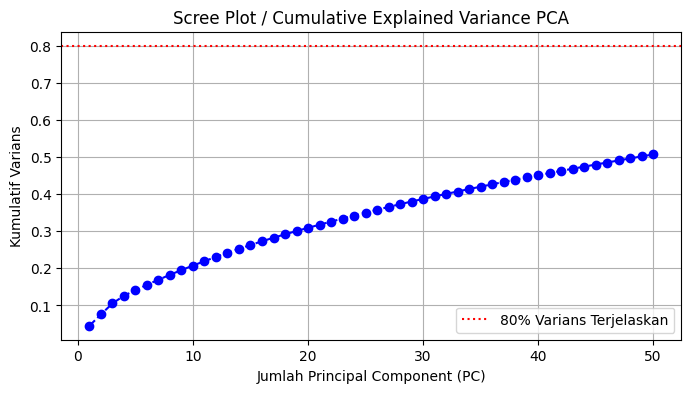

• Varians terjelaskan oleh 2 PC pertama: 7.59%


In [4]:
# 1. Fit PCA dengan seluruh/banyak komponen awal
pca_full = PCA(n_components=50)
pca_full.fit(X)

# 2. Hitung kumulatif varians
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Visualisasi Grafik Cumulative Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varians Terjelaskan')
plt.title('Scree Plot / Cumulative Explained Variance PCA')
plt.xlabel('Jumlah Principal Component (PC)')
plt.ylabel('Kumulatif Varians')
plt.legend()
plt.grid(True)
plt.show()

print(f"• Varians terjelaskan oleh 2 PC pertama: {cumulative_variance[1]*100:.2f}%")

### Aplikasi PCA (Reduksi menjadi 2 Komponen Utama)

Mengompresi ribuan kolom kata unik menjadi 2 Utama (PC1 & PC2) agar dapat dipetakan secara visual dalam koordinat 2D.

In [5]:
# 1. Inisialisasi PCA dengan 2 komponen
pca_2d = PCA(n_components=2, random_state=42)

# 2. Fit & Transform pada data TF-IDF
X_pca = pca_2d.fit_transform(X)

print("=== HASIL REDUKSI DIMENSI PCA (2D) ===")
print(f"• Dimensi Awal  : {X.shape}")
print(f"• Dimensi Akhir : {X_pca.shape}")
print(f"• Rasio Varians PC1 : {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"• Rasio Varians PC2 : {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"• Total Varians     : {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

=== HASIL REDUKSI DIMENSI PCA (2D) ===
• Dimensi Awal  : (200, 5305)
• Dimensi Akhir : (200, 2)
• Rasio Varians PC1 : 4.53%
• Rasio Varians PC2 : 3.05%
• Total Varians     : 7.59%


### Visualisasi Scatter Plot 2D (Sport vs. Finance)

Menggambar sebaran data hasil PCA dalam ruang 2D untuk melihat pemisahan kelompok (clustering/separation) antara kategori Sport (1) dan Finance (0).

In [6]:
import seaborn as sns

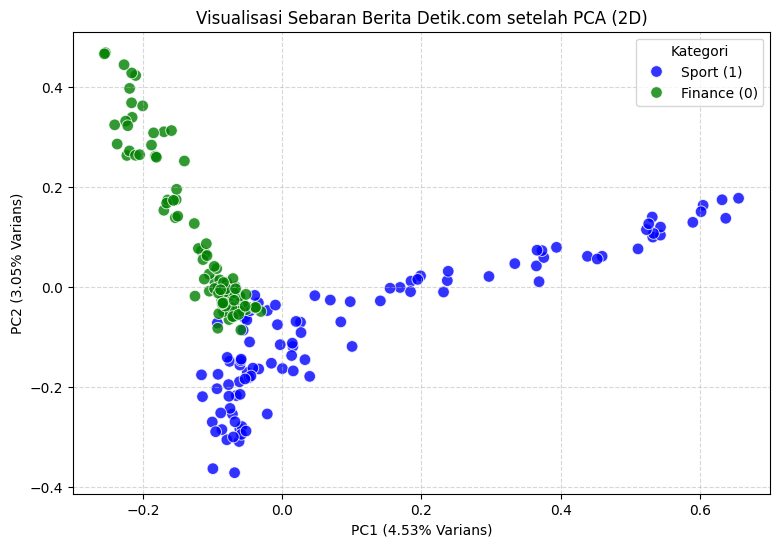

In [7]:
# 1. Buat DataFrame sementara untuk plotting
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['label'] = y.map({1: 'Sport (1)', 0: 'Finance (0)'})

# 2. Visualisasi Scatter Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='label', 
    data=df_plot, 
    palette={'Sport (1)': 'blue', 'Finance (0)': 'green'},
    alpha=0.8, s=70
)

plt.title('Visualisasi Sebaran Berita Detik.com setelah PCA (2D)', fontsize=12)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Varians)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Varians)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Kategori')
plt.show()

### Pembentukan DataFrame & Ekspor Hasil PCA ke CSV

Menyimpan hasil reduksi dimensi PCA ke dalam file CSV sebagai dataset akhir yang siap digunakan untuk pemodelan Machine Learning (seperti Klasifikasi Naive Bayes, SVM, atau K-NN).

In [9]:
# 1. Buat DataFrame PCA
df_pca_result = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# 2. Sisipkan kembali kolom id dan label di awal
df_pca_result.insert(0, 'label', y)
df_pca_result.insert(0, 'id', df_tfidf['id'])

print("=== TABEL HASIL REDUKSI DIMENSI PCA ===")
display(df_pca_result.head())

# 3. Simpan ke file CSV
df_pca_result.to_csv('detik_pca_results.csv', index=False, encoding='utf-8-sig')

print("\n✅ Tahap Reduksi Dimensi dengan PCA Selesai!")
print("💾 File tersimpan sebagai 'detik_pca_results.csv'")

=== TABEL HASIL REDUKSI DIMENSI PCA ===


,id,label,PC1,PC2
0,1,1,-0.053775,-0.061881
1,2,1,-0.075348,-0.148671
2,3,1,-0.050022,-0.170956
3,4,1,-0.065749,-0.217011
4,5,1,0.459458,0.061259



✅ Tahap Reduksi Dimensi dengan PCA Selesai!
💾 File tersimpan sebagai 'detik_pca_results.csv'
